In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 2000)

In [8]:
df = pd.read_csv("./data/04368-0001-Data.csv")

In [9]:
df.head()

,SWANID,HEALTH,LVISIT,HIGH_BP,MHIGHBP,DIABETE,MDIABET,HEART,MHEART,ARTHRIT,MARTHR,OSTEOPR,MOSTEOP,FIBROID,MFIBROD,CANCER,MCANCER,DIFFISLP,NISWEAT,STIFF,HEADACH,HOTFLASH,FORGET,TENSE,DEPRESS,DRYNESS,IRRITAB,HEARTBO,URINE,LIMITED,...,WORK,TOTALHRS,MARITALGP,HOW_HARD,RACE,IND_1A,IND_1B,IND_1C,IND_1D,IND_1E,AGE,LMPMOS,STATUS,MEN_FLAG,HORMEVER,SMOKER,SMOKING,NUM_CIG,DEGREE,P_STRESS,SF36PF,NSF36,DISABLE,BMI,BMI_FLAG,WTKGGP,AGE_R_HYST,AGE_R_OOPH,AGE_R_LMP,NUMCHILD
0,10005,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,Hispanic,NaN,NaN,NaN,NaN,NaN,48,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,10009,Excellent,At least 1 but less than 3 years,No,NaN,Yes,Yes,No,NaN,Yes,No,No,NaN,Yes,No,No,NaN,No,Yes,Yes,Yes,Yes,Yes,No,No,No,Yes,No,Yes,No,...,Yes,35 hours or more,Widowed,Somewhat hard,Black/African American,Yes,No,No,No,No,49,NaN,Natural post,No,Ever used hormones,Not a current smoker,Never smoked,0.0,Some college/technical school,11.0,Does not have a disability or is not limited b...,10.0,Not,40.04,Body Mass Index (BMI) acceptable range,111-115.99 kgs,NaN,NaN,43.0,3 children
2,10011,Good,Less than 1 year,Yes,No,No,NaN,No,NaN,Yes,No,No,NaN,No,NaN,Yes,No,No,No,No,Yes,No,No,Yes,Yes,Yes,Yes,No,Yes,No,...,Yes,35 hours or more,Separated or divorced,Not very hard at all,Black/African American,Yes,No,No,No,No,49,NaN,NaN,No,Never used hormones,Not a current smoker,Never smoked,0.0,Post graduate education,4.0,Does not have a disability or is not limited b...,10.0,Not,28.37,Body Mass Index (BMI) acceptable range,81-85.99 kgs,35.0,NaN,NaN,3 children
3,10022,Very good,Less than 1 year,Yes,Yes,No,NaN,No,NaN,Yes,No,No,NaN,Yes,No,No,NaN,Yes,No,Yes,Yes,No,Yes,Yes,No,Yes,Yes,No,No,Yes,...,Yes,35 hours or more,"Single, never married",Not very hard at all,Caucasian/White Non-Hispanic,No,No,No,No,Yes,52,NaN,NaN,No,Ever used hormones,Not a current smoker,Past smoker,0.0,Post graduate education,7.0,90.0,10.0,Little (sf>50),20.20,Body Mass Index (BMI) acceptable range,51-55.99 kgs,39.0,NaN,NaN,No children
4,10032,Good,At least 1 but less than 3 years,No,NaN,No,NaN,No,NaN,No,NaN,No,NaN,No,NaN,No,NaN,Yes,No,Yes,No,No,No,Yes,Yes,Yes,Yes,No,No,No,...,Yes,35 hours or more,Separated or divorced,Not very hard at all,Caucasian/White Non-Hispanic,No,No,No,No,Yes,46,1.15,Undetermined,No,Ever used hormones,Current smoker,Current smoker,30.0,Less than high school,5.0,Does not have a disability or is not limited b...,10.0,Not,22.84,Body Mass Index (BMI) acceptable range,66-70.99 kgs,NaN,NaN,NaN,2 children


In [10]:
df.shape

(16142, 111)

In [11]:
STATUS = "STATUS"	
MENSTRUATION = "MEN_FLAG"

In [12]:
df[STATUS].value_counts()

STATUS
Premenopausal           4653
Early perimenopausal    3660
Natural post            2293
Undetermined            1185
Late perimenopausal      637
Name: count, dtype: int64

In [13]:
df[MENSTRUATION].value_counts()

MEN_FLAG
No     15673
Yes      418
Name: count, dtype: int64

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16142 entries, 0 to 16141
Columns: 111 entries, SWANID to NUMCHILD
dtypes: float64(13), int64(2), object(96)
memory usage: 13.7+ MB


In [22]:
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

In [42]:
df[numerical_cols].isnull().sum()
missing_pct = df[numerical_cols].isnull().mean().sort_values(ascending=False)*100

missing_cols = missing_pct.index.tolist()[0:13]
missing_cols


['AGE_R_OOPH',
 'AGE_R_LMP',
 'AGE_R_HYST',
 'NO_CIG',
 'LMPMOS',
 'BMI',
 'WT_LBS',
 'WT_KGS',
 'TALLINCH',
 'TALLCM',
 'NUM_CIG',
 'NSF36',
 'CHILDREN']

AGE_R_OOPH , skewness:  -0.5411003216644021
AGE_R_LMP , skewness:  -1.6741302268748957
AGE_R_HYST , skewness:  -0.28908075101098163
NO_CIG , skewness:  1.246291138249856
LMPMOS , skewness:  1.7058447368037788
BMI , skewness:  1.3619616324676556
WT_LBS , skewness:  1.3042787930727728
WT_KGS , skewness:  1.3013599619442306
TALLINCH , skewness:  -0.048355718133412204
TALLCM , skewness:  -0.07337862242693499
NUM_CIG , skewness:  2.8627514912050076
NSF36 , skewness:  -18.10060496775291
CHILDREN , skewness:  0.928337448825764


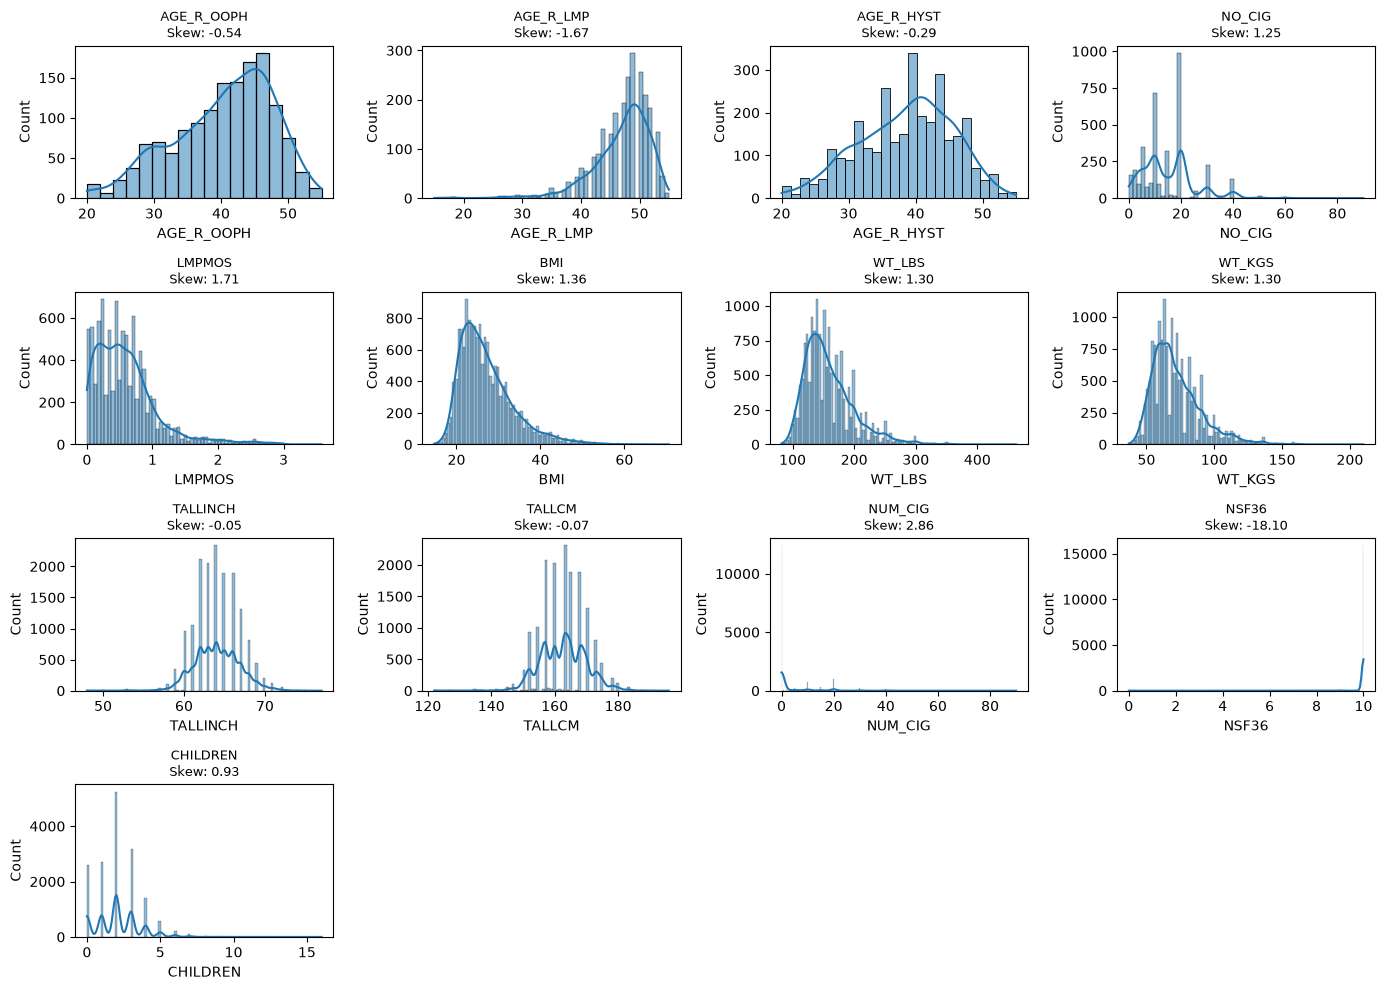

In [49]:
for c in missing_cols:
    print(c, ", skewness: ", df[c].skew())

fig, axes = plt.subplots(4, 4, figsize=(14, 10))
axes = axes.flatten()
for i, col in enumerate(missing_cols):
    if i < len(axes):
        sns.histplot(df[col].dropna(), kde=True, ax=axes[i])
        axes[i].set_title(f"{col}\nSkew: {df[col].skew():.2f}", fontsize=9)

for j in range(len(missing_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()